In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\user\Downloads\healthcare ml.xlsx")
df.head()

,Patient_ID,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Blood_Glucose_mgdL,Hemoglobin_gdL,Heart_Rate_bpm,Temperature_C,...,Prev_Admissions,Smoker,Alcohol_Use,Exercise_Frequency,Education_Level,Urban_Rural,Insurance_Type,Admission_Type,Blood_Type,Readmitted_30days
0,PAT-00001,62,Male,28.9,184,75,104,9.9,72,39.2,...,2,0,1,Never,Tertiary,Urban,NHIS,Emergency,O-,0
1,PAT-00002,42,Female,23.6,142,87,316,7.8,58,38.4,...,7,1,0,Often,Secondary,Rural,HMO,Referral,A-,0
2,PAT-00003,83,Male,40.1,96,113,87,11.6,60,37.3,...,6,0,1,Rarely,Tertiary,Rural,NHIS,Elective,B+,0
3,PAT-00004,69,Male,18.3,99,116,93,13.8,96,36.8,...,1,0,0,Often,Primary,Rural,Out-of-Pocket,Elective,AB-,0
4,PAT-00005,58,Male,27.9,128,85,347,15.7,98,38.9,...,0,1,0,Rarely,Secondary,Urban,HMO,Walk-in,A+,0


In [3]:
df['Education_Level'] = df['Education_Level'].fillna('Unknown')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2500 non-null   str    
 1   Age                  2500 non-null   int64  
 2   Gender               2500 non-null   str    
 3   BMI                  2500 non-null   float64
 4   Systolic_BP          2500 non-null   int64  
 5   Diastolic_BP         2500 non-null   int64  
 6   Blood_Glucose_mgdL   2500 non-null   int64  
 7   Hemoglobin_gdL       2500 non-null   float64
 8   Heart_Rate_bpm       2500 non-null   int64  
 9   Temperature_C        2500 non-null   float64
 10  Diagnosis            2500 non-null   str    
 11  Department           2500 non-null   str    
 12  Length_of_Stay_Days  2500 non-null   int64  
 13  Num_Medications      2500 non-null   int64  
 14  Num_Comorbidities    2500 non-null   int64  
 15  Prev_Admissions      2500 non-null   int64  
 16 

In [5]:
df.drop(columns = ["Patient_ID"], inplace = True)
df.head()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Blood_Glucose_mgdL,Hemoglobin_gdL,Heart_Rate_bpm,Temperature_C,Diagnosis,...,Prev_Admissions,Smoker,Alcohol_Use,Exercise_Frequency,Education_Level,Urban_Rural,Insurance_Type,Admission_Type,Blood_Type,Readmitted_30days
0,62,Male,28.9,184,75,104,9.9,72,39.2,Fracture,...,2,0,1,Never,Tertiary,Urban,NHIS,Emergency,O-,0
1,42,Female,23.6,142,87,316,7.8,58,38.4,Tuberculosis,...,7,1,0,Often,Secondary,Rural,HMO,Referral,A-,0
2,83,Male,40.1,96,113,87,11.6,60,37.3,Appendicitis,...,6,0,1,Rarely,Tertiary,Rural,NHIS,Elective,B+,0
3,69,Male,18.3,99,116,93,13.8,96,36.8,Tuberculosis,...,1,0,0,Often,Primary,Rural,Out-of-Pocket,Elective,AB-,0
4,58,Male,27.9,128,85,347,15.7,98,38.9,Fracture,...,0,1,0,Rarely,Secondary,Urban,HMO,Walk-in,A+,0


In [6]:
df.isnull().sum()

Age                    0
Gender                 0
BMI                    0
Systolic_BP            0
Diastolic_BP           0
Blood_Glucose_mgdL     0
Hemoglobin_gdL         0
Heart_Rate_bpm         0
Temperature_C          0
Diagnosis              0
Department             0
Length_of_Stay_Days    0
Num_Medications        0
Num_Comorbidities      0
Prev_Admissions        0
Smoker                 0
Alcohol_Use            0
Exercise_Frequency     0
Education_Level        0
Urban_Rural            0
Insurance_Type         0
Admission_Type         0
Blood_Type             0
Readmitted_30days      0
dtype: int64

In [7]:
df.shape

(2500, 24)

In [8]:
df.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,Blood_Glucose_mgdL,Hemoglobin_gdL,Heart_Rate_bpm,Temperature_C,Length_of_Stay_Days,Num_Medications,Num_Comorbidities,Prev_Admissions,Smoker,Alcohol_Use,Readmitted_30days
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,44.598000,28.957360,144.195200,89.676400,212.23280,12.51728,89.175200,38.287160,15.106400,5.547600,1.985200,4.540800,0.357600,0.304000,0.292000
std,25.686906,7.553875,31.700193,17.730534,81.51598,3.18425,23.081404,1.306321,8.562593,3.424679,1.419925,2.841331,0.479389,0.460075,0.454773
min,1.000000,16.000000,90.000000,60.000000,70.00000,7.00000,50.000000,36.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,22.400000,117.000000,74.000000,143.00000,9.80000,69.000000,37.200000,8.000000,3.000000,1.000000,2.000000,0.000000,0.000000,0.000000
50%,44.000000,28.900000,145.000000,90.000000,213.00000,12.60000,90.000000,38.300000,15.000000,6.000000,2.000000,5.000000,0.000000,0.000000,0.000000
75%,67.000000,35.600000,172.000000,105.000000,285.25000,15.30000,108.000000,39.400000,23.000000,8.000000,3.000000,7.000000,1.000000,1.000000,1.000000
max,89.000000,42.000000,199.000000,119.000000,349.00000,18.00000,129.000000,40.500000,29.000000,11.000000,4.000000,9.000000,1.000000,1.000000,1.000000


## TARGET VARIABLE ANALYSIS

In [9]:
print(df['Readmitted_30days'].value_counts())

Readmitted_30days
0    1770
1     730
Name: count, dtype: int64


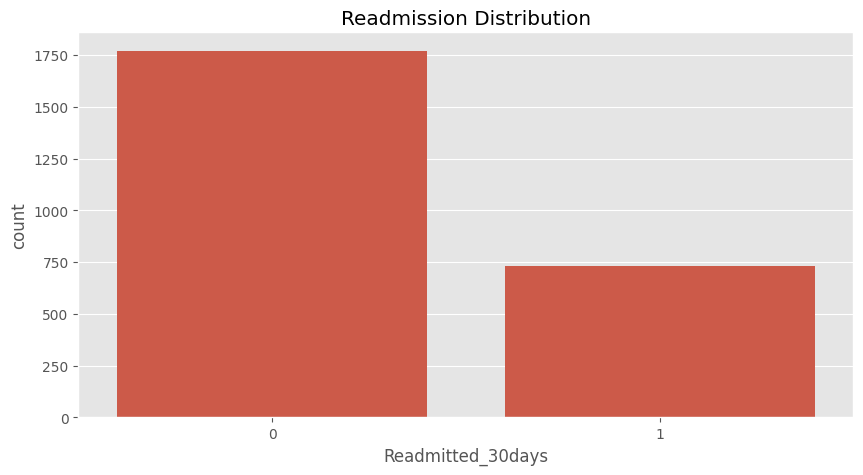

In [10]:
plt.style.use("ggplot")
plt.figure(figsize =(10,5))
sns.countplot(
    x='Readmitted_30days',
    data=df
)

plt.title("Readmission Distribution")
plt.show()

In [11]:
df['Readmitted_30days'].value_counts(normalize=True)*100

Readmitted_30days
0    70.8
1    29.2
Name: proportion, dtype: float64

In [14]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
numerical_cols

Index(['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Blood_Glucose_mgdL',
       'Hemoglobin_gdL', 'Heart_Rate_bpm', 'Temperature_C',
       'Length_of_Stay_Days', 'Num_Medications', 'Num_Comorbidities',
       'Prev_Admissions', 'Smoker', 'Alcohol_Use', 'Readmitted_30days'],
      dtype='str')

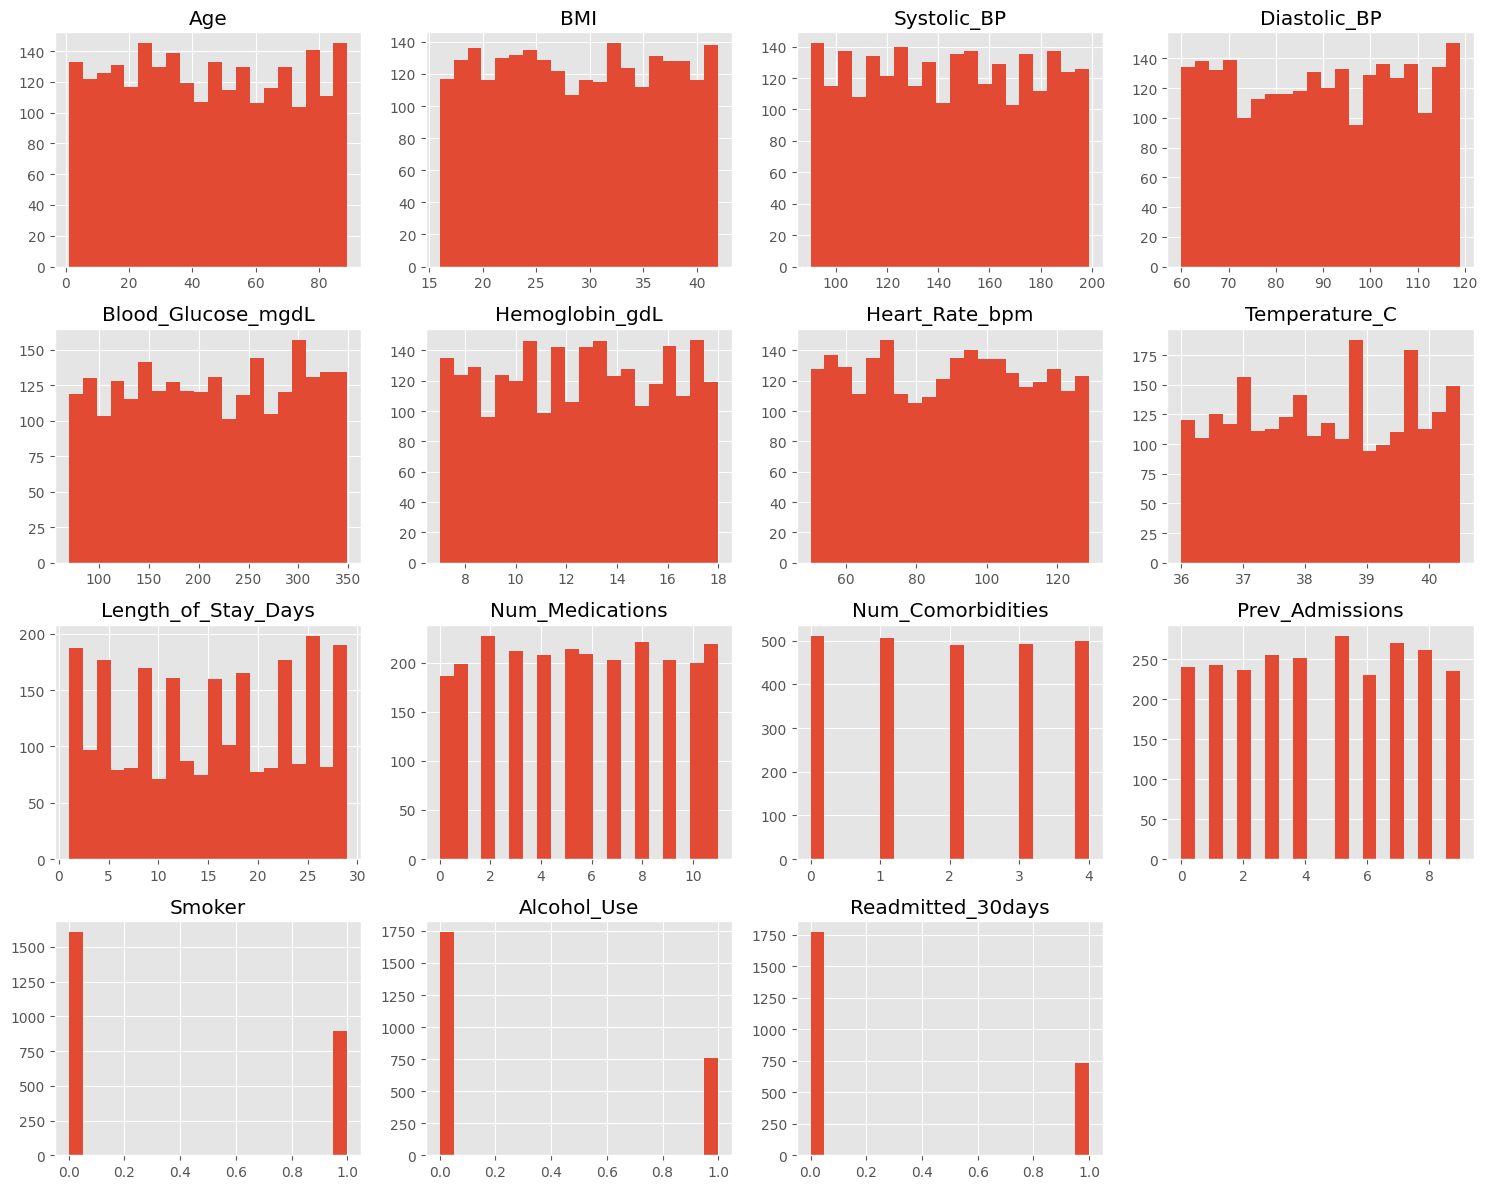

In [15]:
df[numerical_cols].hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

In [12]:
categorical_cols = df.select_dtypes( include='str').columns

print(categorical_cols)

Index(['Gender', 'Diagnosis', 'Department', 'Exercise_Frequency',
       'Education_Level', 'Urban_Rural', 'Insurance_Type', 'Admission_Type',
       'Blood_Type'],
      dtype='str')


In [13]:
# Using resampling.
from sklearn.utils import resample
df0 = df[df['Readmitted_30days'] == 0]
df1 = df[df['Readmitted_30days'] == 1]
df0_sam = resample(df0, replace = True, n_samples= 730)

sample_df = pd.concat([df0_sam,df1])

df = sample_df.sample(frac = 1, ignore_index = True)


## ENCODING CATEGORICAL VALUES

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include= 'str').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Blood_Glucose_mgdL', 'Hemoglobin_gdL', 'Heart_Rate_bpm',
       'Temperature_C', 'Diagnosis', 'Department', 'Length_of_Stay_Days',
       'Num_Medications', 'Num_Comorbidities', 'Prev_Admissions', 'Smoker',
       'Alcohol_Use', 'Exercise_Frequency', 'Education_Level', 'Urban_Rural',
       'Insurance_Type', 'Admission_Type', 'Blood_Type', 'Readmitted_30days'],
      dtype='str')

## SPLIT FEATURES AND TARGETS

In [20]:
X = df.drop('Readmitted_30days', axis=1)
y = df['Readmitted_30days']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )

## FEATURE SCALING

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## TRAINING 2 CLASSIFICATION MODEL

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## EVALUATING THE MODEL

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [26]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy:
0.5993150684931506
              precision    recall  f1-score   support

           0       0.60      0.61      0.60       146
           1       0.60      0.59      0.60       146

    accuracy                           0.60       292
   macro avg       0.60      0.60      0.60       292
weighted avg       0.60      0.60      0.60       292



In [27]:
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy:
0.6061643835616438
              precision    recall  f1-score   support

           0       0.60      0.62      0.61       146
           1       0.61      0.59      0.60       146

    accuracy                           0.61       292
   macro avg       0.61      0.61      0.61       292
weighted avg       0.61      0.61      0.61       292



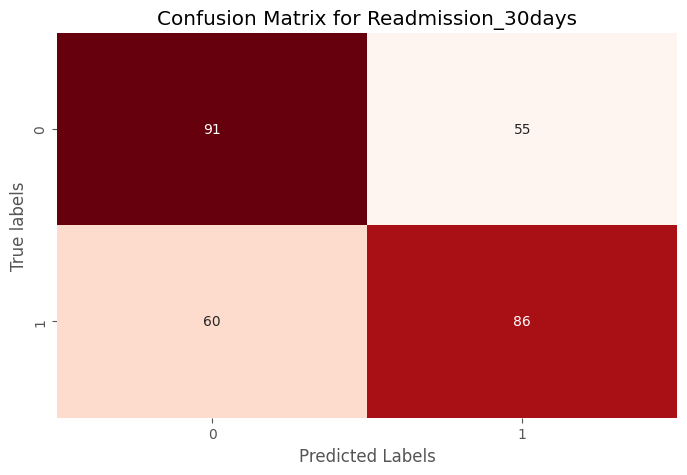

In [28]:
# calculate confusion matrix
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize= (8, 5))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Reds", cbar = False)
plt.xlabel("Predicted Labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix for Readmission_30days")
plt.show()

In [29]:
import joblib as jb
jb.dump(rf, "healthcare_model.pkl")

['healthcare_model.pkl']